# 01 — Dataset inspection and label interpretation

This notebook performs the initial inspection of the Brugada-HUCA 1.0.0 dataset. It establishes the assumptions and basic checks used throughout the project.

The goal is to understand the data structure, define a clear interpretation of the labels, and confirm that the ECG records can be loaded before moving into morphology analysis and modelling.


## 1. Dataset context and project interpretation

After clarification from the dataset author, the following interpretation is used in this project.

| Variable | Interpretation in this project |
|---|---|
| `brugada` | **Final diagnostic label** indicating the subject's Brugada syndrome status |
| `brugada = 0` | Non-Brugada / normal diagnostic class |
| `brugada = 1` | Confirmed Brugada syndrome |
| `brugada = 2` | Confirmed Brugada syndrome after an initially inconclusive ECG and a positive flecainide test |
| `brugada > 0` | Positive class for the main binary task |
| `basal_pattern` | Describes the **baseline / initial ECG morphology before additional diagnostic testing**, including before flecainide administration |
| `basal_pattern = 0` | No Brugada-type pattern identified in the baseline ECG |
| `basal_pattern = 1` | Baseline ECG with a Brugada-type / Brugada-like pattern; not necessarily a definitive diagnostic type I pattern |
| `sudden_death` | Clinical history variable; not used as an ECG input feature |

Important clarification:

- All Brugada-positive cases are treated as **Brugada type I**.
- The ECGs included in the dataset correspond to the **final ECG used to decide the diagnostic class**, not random baseline snapshots.
- For the main binary task, `brugada > 0` is used as the Brugada-positive class.
- `brugada = 2` indicates flecainide-confirmed Brugada, not a separate ECG subtype.
- The `basal_pattern` variable reflects initial baseline ECG morphology, not the final diagnosis. It is therefore used only for subgroup/error analysis and excluded from ECG-only model inputs to avoid leakage.

The main project task should be framed as:

> **Comparative ECG morphology analysis and ECG-only classification of final diagnostic ECGs: Brugada type I vs non-Brugada.**

### Lead strategy

Brugada syndrome is primarily assessed in the **right precordial leads (V1–V3), especially V1–V2**. Therefore, the morphology analysis and initial feature-engineering steps should be **V1–V3-centered**.

However, the full 12-lead ECGs are still inspected at this stage to:

- confirm that the recordings and leads load correctly;
- visually check signal quality and obvious artefacts;
- provide context beyond the right precordial leads;
- support later comparison between **V1–V3-centered** and **12-lead** approaches.

Practical decision for this project:

> The project is **V1–V3-centered**, not strictly **V1–V3-only**.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
import os


In [2]:
# Lead groups used throughout the project
#
# RIGHT_PRECORDIAL_LEADS are the primary leads for Brugada morphology.
#
# LATERAL_LEADS are retained as supporting context when reviewing RBBB-like
# morphology. In true RBBB, the V1–V3 pattern is usually accompanied by
# wide/slurred S waves in lateral leads such as I, aVL, V5 and V6.
# Their role is not to diagnose Brugada, but to help identify whether the
# right-precordial pattern may be influenced by a broader conduction pattern
# such as true RBBB.

RIGHT_PRECORDIAL_LEADS = ["V1", "V2", "V3"]
LATERAL_LEADS = ["I", "aVL", "V5", "V6"]
BRUGADA_CONTEXT_LEADS = RIGHT_PRECORDIAL_LEADS + LATERAL_LEADS

RIGHT_PRECORDIAL_LEADS, LATERAL_LEADS, BRUGADA_CONTEXT_LEADS


(['V1', 'V2', 'V3'],
 ['I', 'aVL', 'V5', 'V6'],
 ['V1', 'V2', 'V3', 'I', 'aVL', 'V5', 'V6'])

## 2. Load and inspect metadata

Each row in `metadata.csv` corresponds to one subject/ECG record, identified by `patient_id`.

The initial dataset documentation described `brugada` as binary, although the released metadata contained values `0`, `1`, and `2`. Based on clarification from the dataset author, `brugada = 2` is treated as a Brugada-positive subgroup confirmed after flecainide testing.

Expected project structure:

```text
ecg-brugada-screening/
├── data/
│   └── raw/
│       └── brugada-huca-1.0.0/
└── notebooks/
    └── 01_dataset_inspection.ipynb
```


In [3]:
# This cell defines the main paths used throughout the notebook and
# checks whether the expected dataset folders and files exist.
#
# This notebook is assumed to be inside the notebooks/ folder.
# Because this notebook is inside notebooks/, os.path.abspath("..")
# points to the project root directory.
#
# os.path: this module implements useful functions for pathname manipulation.

PROJECT_ROOT = os.path.abspath("..")

DATASET_DIR = os.path.join(PROJECT_ROOT, "data", "raw", "brugada-huca-1.0.0")
FILES_DIR = os.path.join(DATASET_DIR, "files")
METADATA_PATH = os.path.join(DATASET_DIR, "metadata.csv")

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset directory exists: {os.path.exists(DATASET_DIR)} -> {DATASET_DIR}")
print(f"Metadata file exists: {os.path.exists(METADATA_PATH)} -> {METADATA_PATH}")
print(f"Files directory exists: {os.path.exists(FILES_DIR)} -> {FILES_DIR}")


Project root: C:\Users\nuno_\Documents\ecg-brugada-screening
Dataset directory exists: True -> C:\Users\nuno_\Documents\ecg-brugada-screening\data\raw\brugada-huca-1.0.0
Metadata file exists: True -> C:\Users\nuno_\Documents\ecg-brugada-screening\data\raw\brugada-huca-1.0.0\metadata.csv
Files directory exists: True -> C:\Users\nuno_\Documents\ecg-brugada-screening\data\raw\brugada-huca-1.0.0\files


In [4]:
metadata = pd.read_csv(METADATA_PATH)

print(metadata.head())


   patient_id  basal_pattern  sudden_death  brugada
0      188981              1             0        1
1      251972              0             0        0
2      265715              0             0        0
3      267628              0             0        0
4      267630              0             0        1


In [5]:
metadata.info()


<class 'pandas.DataFrame'>
RangeIndex: 363 entries, 0 to 362
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   patient_id     363 non-null    int64
 1   basal_pattern  363 non-null    int64
 2   sudden_death   363 non-null    int64
 3   brugada        363 non-null    int64
dtypes: int64(4)
memory usage: 11.5 KB


In [6]:
# Check column types, unique values, and missing values.
metadata_column_summary = pd.DataFrame({
    "dtype": metadata.dtypes,
    "n_unique": metadata.nunique(dropna=False),
    "n_missing": metadata.isna().sum(),
})

print(metadata_column_summary)


               dtype  n_unique  n_missing
patient_id     int64       363          0
basal_pattern  int64         2          0
sudden_death   int64         2          0
brugada        int64         3          0


In [7]:
# Check the raw value counts for the core metadata columns.
core_columns = ["basal_pattern", "sudden_death", "brugada"]

for col in core_columns:
    counts = metadata[col].value_counts(dropna=False).sort_index()
    counts.index.name = None
    print(f"{col}:")
    print(counts)
    print()


basal_pattern:
0    317
1     46
Name: count, dtype: int64

sudden_death:
0    352
1     11
Name: count, dtype: int64

brugada:
0    287
1     69
2      7
Name: count, dtype: int64



In [8]:
# Summarise the main diagnostic counts after author clarification.
# For the binary task, brugada > 0 is treated as Brugada-positive.
#
# int() keeps the summary values as standard Python integers for reporting/export.

diagnostic_count_summary = pd.Series({
    "total_records": len(metadata),
    "non_brugada": int((metadata["brugada"] == 0).sum()),
    "brugada_positive": int((metadata["brugada"] > 0).sum()),
    "flecainide_confirmed_brugada_2": int((metadata["brugada"] == 2).sum()),
})

diagnostic_count_summary


total_records                     363
non_brugada                       287
brugada_positive                   76
flecainide_confirmed_brugada_2      7
dtype: int64

## 3. Create interpreted labels

The raw metadata columns are kept unchanged. New derived variables are added only to make the project interpretation explicit and easier to reuse in later notebooks.

The main derived target is `brugada_syndrome`, where all records with `brugada > 0` are treated as Brugada-positive.

The initial baseline ECG morphology is not the main target because it does not represent the final diagnostic class. The corresponding `basal_pattern` variable is kept only for subgroup/error analysis and excluded from ECG-only model inputs to avoid leakage.


In [9]:
# Keep the original metadata values unchanged and add interpreted columns.
metadata = metadata.copy()

# Main binary target for the project.
metadata["brugada_syndrome"] = (metadata["brugada"] > 0).astype(int)

# Readable diagnostic groups.
diagnosis_map = {
    0: "non_brugada",
    1: "brugada_type_I",
    2: "brugada_type_I_flecainide_confirmed",
}

# Readable labels for the initial/baseline ECG morphology.
basal_pattern_map = {
    0: "initial_ecg_no_brugada_type_pattern",
    1: "initial_ecg_brugada_type_like_pattern",
}

metadata["diagnostic_group"] = metadata["brugada"].map(diagnosis_map)
metadata["basal_pattern_group"] = metadata["basal_pattern"].map(basal_pattern_map)

metadata[[
    "patient_id",
    "basal_pattern",
    "basal_pattern_group",
    "brugada_syndrome",
    "diagnostic_group",
]].head()


,patient_id,basal_pattern,basal_pattern_group,brugada_syndrome,diagnostic_group
0,188981,1,initial_ecg_brugada_type_like_pattern,1,brugada_type_I
1,251972,0,initial_ecg_no_brugada_type_pattern,0,non_brugada
2,265715,0,initial_ecg_no_brugada_type_pattern,0,non_brugada
3,267628,0,initial_ecg_no_brugada_type_pattern,0,non_brugada
4,267630,0,initial_ecg_no_brugada_type_pattern,1,brugada_type_I


### Relationship between baseline pattern and final diagnosis

The `basal_pattern` column refers to the **initial baseline ECG**, not necessarily to the final ECG included in the dataset.

This matters because some subjects had additional diagnostic steps after the initial ECG, such as a **repeated ECG or flecainide testing**. Therefore, `basal_pattern` should be used as baseline-context information for error analysis.

The table below is a cross-tabulation, similar to a pivot table. It helps identify subgroups to track in later analyses, while keeping the main modelling task binary.


In [10]:
# pd.crosstab(index, columns, values=None, rownames=None, colnames=None,
# aggfunc=None, margins=False, margins_name='All', dropna=True, normalize=False)

pd.crosstab(
    metadata["basal_pattern_group"], # Values to group by in the rows.
    metadata["diagnostic_group"], # Values to group by in the columns.
    rownames=["baseline ECG context"],
    colnames=["final diagnostic group"],
    margins=True, # Add row/column margins (subtotals).
)


final diagnostic group,brugada_type_I,brugada_type_I_flecainide_confirmed,non_brugada,All
baseline ECG context,,,,
initial_ecg_brugada_type_like_pattern,19,4,23,46
initial_ecg_no_brugada_type_pattern,50,3,264,317
All,69,7,287,363


## 4. Check ECG files and load one example

Each patient should have a WFDB header file (`.hea`) and signal file (`.dat`) under:

```text
data/raw/brugada-huca-1.0.0/files/{patient_id}/{patient_id}.hea
data/raw/brugada-huca-1.0.0/files/{patient_id}/{patient_id}.dat
```

This section checks that the files exist, loads one example record, verifies the lead names, and produces simple inspection plots.


In [11]:
def expected_record_paths(patient_id):
    """Return the expected WFDB file paths for one patient_id."""
    patient_id = str(patient_id)
    record_dir = os.path.join(FILES_DIR, patient_id)

    return {
        "hea_path": os.path.join(record_dir, f"{patient_id}.hea"),
        "dat_path": os.path.join(record_dir, f"{patient_id}.dat"),
        "record_base": os.path.join(record_dir, patient_id), # Base WFDB path; .hea and .dat are inferred by wfdb.rdrecord().
    }

file_checks = []

for patient_id in metadata["patient_id"]:
    paths = expected_record_paths(patient_id) # Dictionary of expected paths for this patient.

    file_checks.append({
        "patient_id": patient_id,
        "hea_exists": os.path.exists(paths["hea_path"]),
        "dat_exists": os.path.exists(paths["dat_path"]),
    })

file_checks = pd.DataFrame(file_checks)

missing_files = file_checks.loc[
    ~(file_checks["hea_exists"] & file_checks["dat_exists"])
]

file_checks_summary = pd.Series({
    "n_records_checked": len(file_checks),
    "all_hea_files_found": file_checks["hea_exists"].all(), # .all() returns True only if all values in the Series are True.
    "all_dat_files_found": file_checks["dat_exists"].all(),
    "n_records_with_missing_files": len(missing_files),
})

file_checks_summary

n_records_checked                363
all_hea_files_found             True
all_dat_files_found             True
n_records_with_missing_files       0
dtype: object

In [12]:
def load_record(patient_id):
    """Load a WFDB record by patient_id."""
    paths = expected_record_paths(patient_id)
    return wfdb.rdrecord(paths["record_base"])

# Load the first ECG record as a simple sanity check.
example_patient_id = metadata["patient_id"].iloc[0]
record = load_record(example_patient_id)

print(f"Example patient_id: {example_patient_id}")
print(f"Signal shape: {record.p_signal.shape}")
print(f"Sampling frequency: {record.fs} Hz")
print(f"Number of leads: {record.n_sig}")
print(f"Signal length: {record.sig_len} samples")
print(f"Duration: {record.sig_len / record.fs} seconds")
print(f"Lead names: {record.sig_name}")
print(f"Units: {record.units}")


Example patient_id: 188981
Signal shape: (1200, 12)
Sampling frequency: 100 Hz
Number of leads: 12
Signal length: 1200 samples
Duration: 12.0 seconds
Lead names: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Units: ['mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV']


In [13]:
def plot_record(record, leads, seconds=None, title="ECG"):
    """Plot selected leads from a WFDB record."""

    # Create the time axis in seconds.
    # record.sig_len = number of samples; record.fs = sampling frequency in Hz.
    time = np.arange(record.sig_len) / record.fs

    # If seconds is provided, keep only the first seconds of the signal.
    # Otherwise, keep the full recording.
    if seconds is not None:
        keep = time <= seconds
    else:
        keep = np.ones(len(time), dtype=bool)

    # Map each lead name to its column index in record.p_signal.
    # Example: {"I": 0, "II": 1, ..., "V1": 6, ...}
    lead_to_index = {lead: i for i, lead in enumerate(record.sig_name)}

    plt.figure(figsize=(12, 2.2 * len(leads)))

    for i, lead in enumerate(leads, start=1):
        idx = lead_to_index[lead]

        # Create one subplot per lead.
        # Arguments: number of rows, number of columns, current subplot index.
        plt.subplot(len(leads), 1, i)

        # record.p_signal is a 2D array: rows = time samples, columns = leads.
        plt.plot(time[keep], record.p_signal[keep, idx], linewidth=1)

        plt.ylabel(f"{lead} (mV)")
        plt.grid(True, alpha=0.3)

    plt.xlabel("Time (s)")
    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


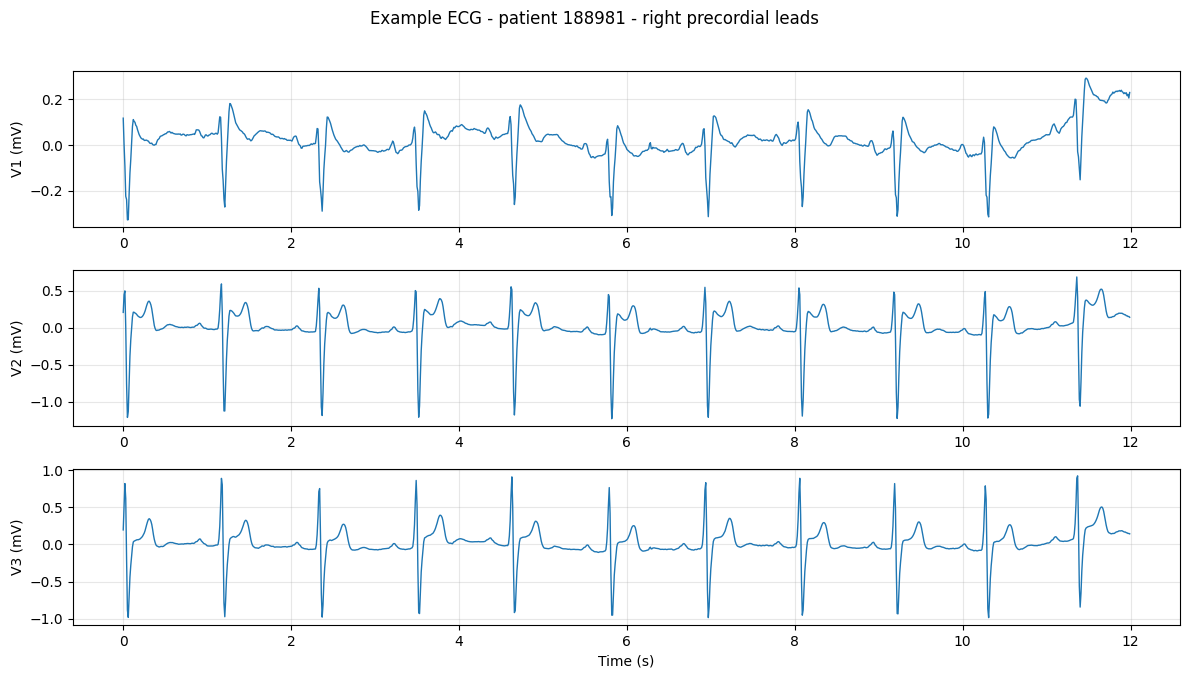

In [14]:
plot_record(
    record,
    leads=RIGHT_PRECORDIAL_LEADS,
    title=f"Example ECG - patient {example_patient_id} - right precordial leads"
)


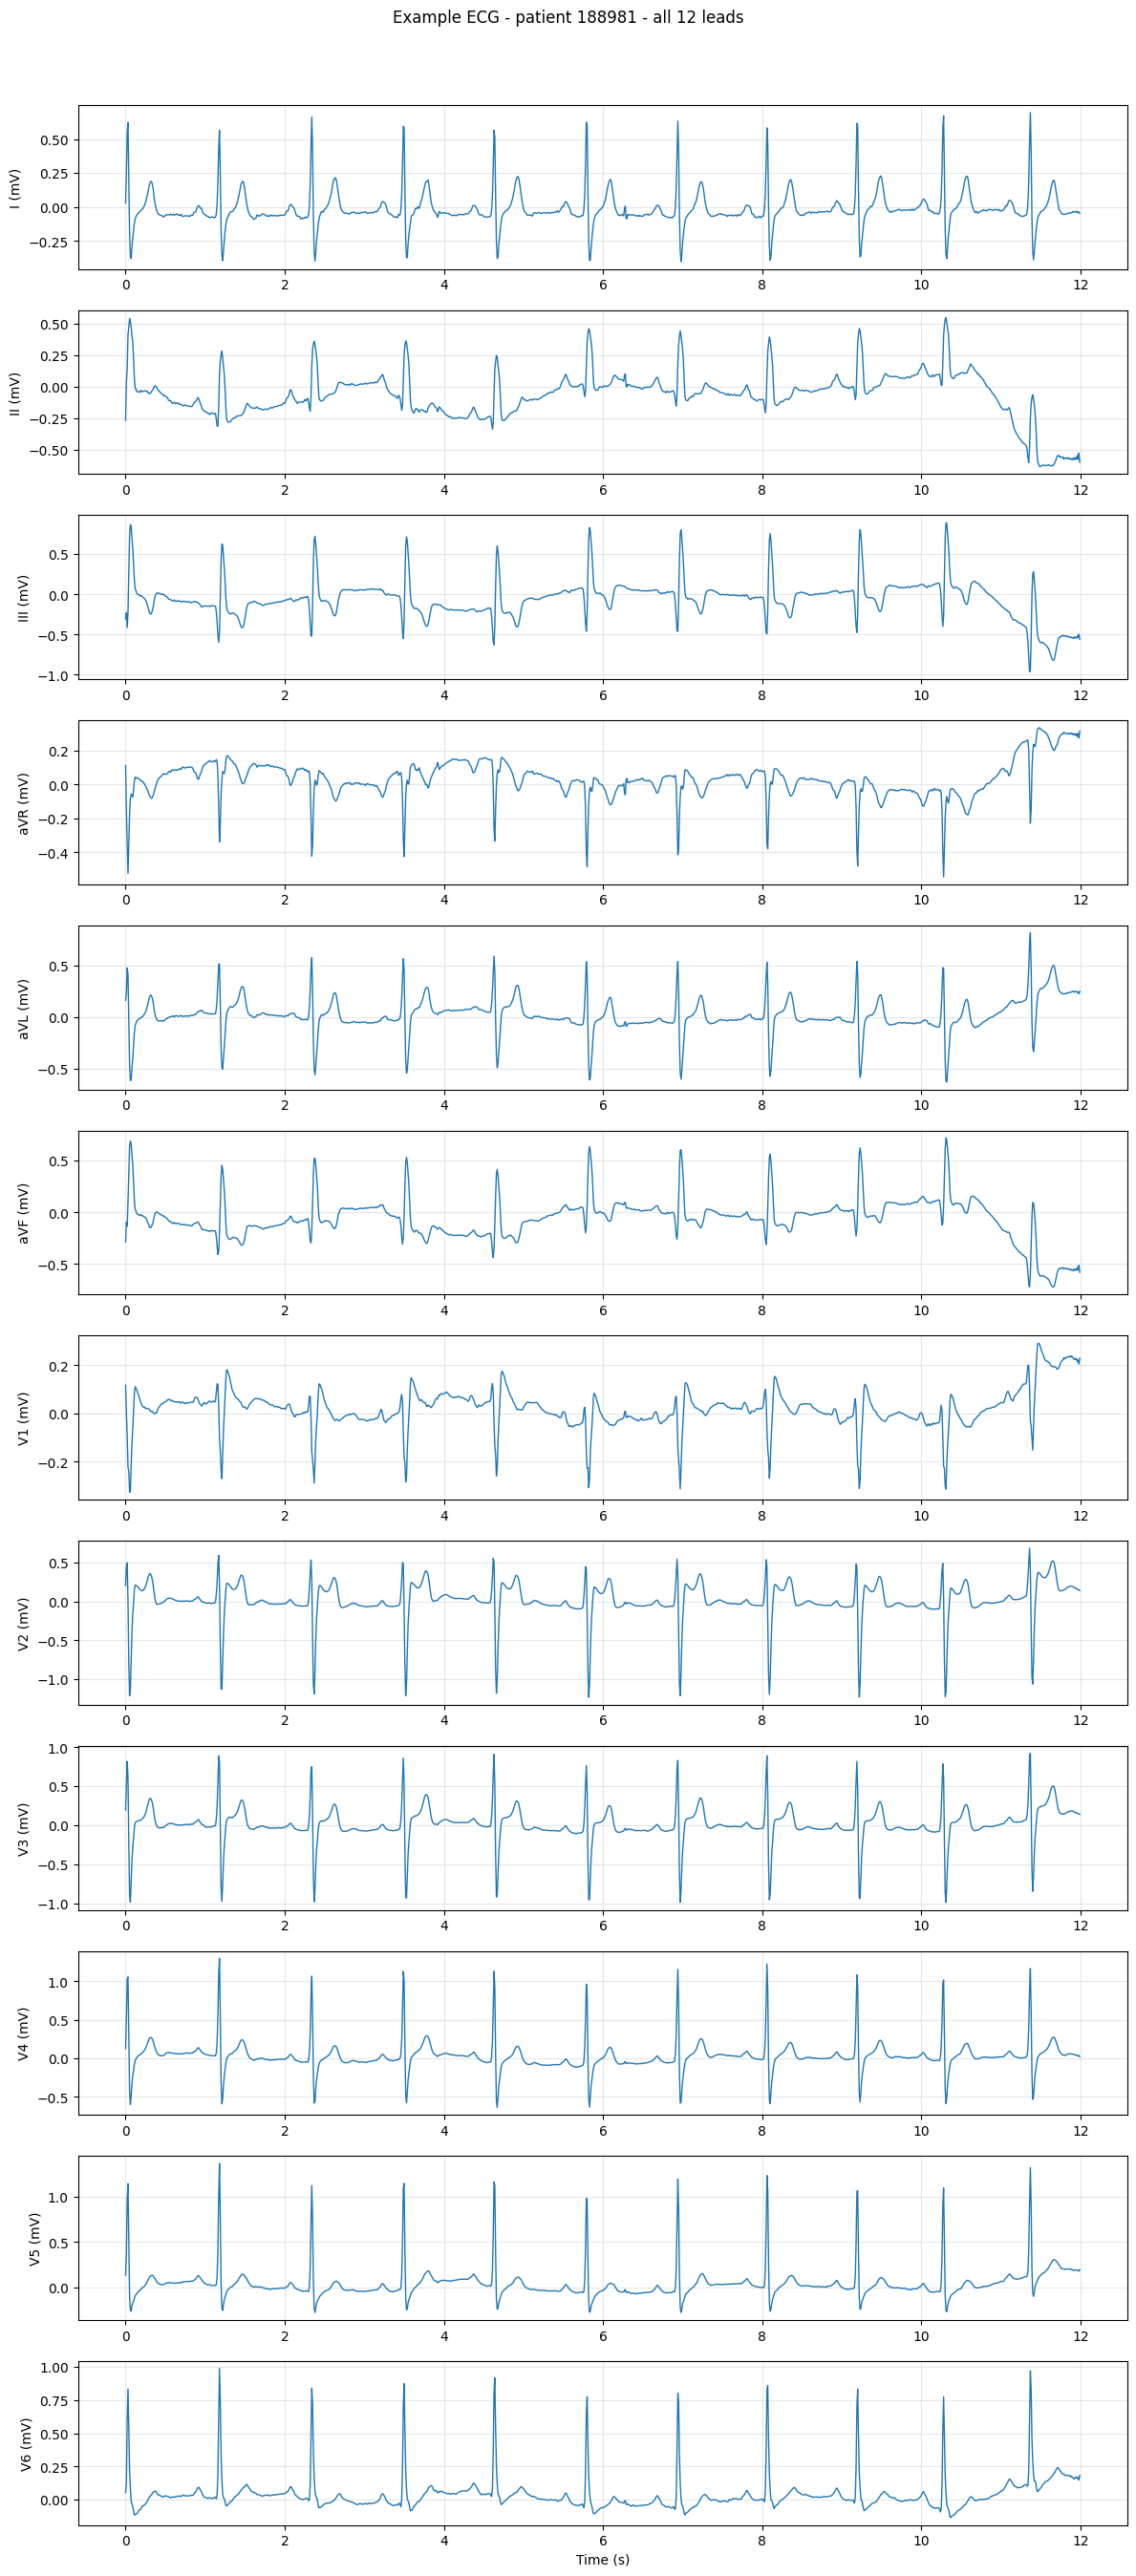

In [15]:
plot_record(
    record,
    leads=record.sig_name,
    title=f"Example ECG - patient {example_patient_id} - all 12 leads"
)


## 5. Save interpreted metadata and next steps

This step saves a processed metadata file with the derived labels. Later notebooks should load this file to avoid redefining the label logic repeatedly.


In [16]:
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
os.makedirs(PROCESSED_DIR, exist_ok=True)

INTERPRETED_METADATA_PATH = os.path.join(PROCESSED_DIR, "metadata_interpreted.csv")

metadata.to_csv(INTERPRETED_METADATA_PATH, index=False)

print(f"Saved interpreted metadata to: {INTERPRETED_METADATA_PATH}")


Saved interpreted metadata to: C:\Users\nuno_\Documents\ecg-brugada-screening\data\processed\metadata_interpreted.csv


### Summary of decisions

The following decisions will be used in the next notebooks:

1. The main binary target is `brugada_syndrome = (brugada > 0)`.
2. `brugada = 2` is retained as a positive Brugada type I subgroup confirmed after flecainide testing.
3. `basal_pattern` describes the baseline ECG before additional testing, not necessarily the final diagnostic ECG included in the dataset.
4. `basal_pattern` is used for subgroup/context analysis only.
5. The main project focus is **Brugada type I vs non-Brugada using final diagnostic ECGs**.
6. The project is **V1–V3-centered**, not strictly V1–V3-only.

The next notebook should focus on **comparative ECG morphology analysis**, especially in V1–V3, with the remaining leads used as supporting context when needed.
